In [ ]:
import pandas as pd
df = pd.read_csv("/content/drive/MyDrive/industrial-ai-project/data/processed/metropt3_features.csv")
df['timestamp'] = pd.to_datetime(df['timestamp'])

# Recreate the same chronological train/test split as before
split_date = pd.to_datetime("2020-06-08 00:00:00")
train_df = df[df['timestamp'] < split_date]
test_df = df[df['timestamp'] >= split_date]

# Recreate the same feature columns and X/y split used in classification
feature_cols = [
    'TP2_rolling_mean', 'TP2_rolling_max', 'TP2_rolling_std',
    'H1_rolling_mean', 'H1_rolling_max', 'H1_rolling_std',
    'Oil_temperature_rolling_mean', 'Oil_temperature_rolling_max', 'Oil_temperature_rolling_std',
    'Motor_current_rolling_mean', 'Motor_current_rolling_max', 'Motor_current_rolling_std'
]

X_train = train_df[feature_cols]
y_train = train_df['is_failure']

X_test = test_df[feature_cols]
y_test = test_df['is_failure']

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (150265, 12)
Test shape: (101127, 12)


In [ ]:
from sklearn.ensemble import IsolationForest
from sklearn.metrics import classification_report
import numpy as np

# Train on normal operation data only (no leakage - Train set only)
X_train_normal = X_train[y_train == 0]

iso_forest_v4 = IsolationForest(random_state=42)
iso_forest_v4.fit(X_train_normal)

# Get anomaly scores for test data (higher score = more anomalous)
scores = -iso_forest_v4.score_samples(X_test)

# Set threshold based on TRAIN set's failure ratio (no leakage)
train_contamination = y_train.mean()
threshold = np.percentile(scores, 100 * (1 - train_contamination))

anomaly_pred_binary_v4 = (scores >= threshold).astype(int)

print(f"Contamination rate used (from Train): {train_contamination:.4f}")
print(classification_report(y_test, anomaly_pred_binary_v4))

Contamination rate used (from Train): 0.0311
              precision    recall  f1-score   support

           0       1.00      0.96      0.98    100861
           1       0.06      0.97      0.11       266

    accuracy                           0.96    101127
   macro avg       0.53      0.96      0.54    101127
weighted avg       1.00      0.96      0.98    101127



In [ ]:
# --- Scenario 2: Balanced Threshold (High Precision & F1-Score) ---
# Cut-off at 99.5th percentile to significantly reduce false alarms
threshold_balanced = np.percentile(scores, 99.5)
y_pred_balanced = (scores >= threshold_balanced).astype(int)

print("=== Scenario 2: Balanced Threshold (99.5th Percentile) ===")
print(classification_report(y_test, y_pred_balanced))

=== Scenario 2: Balanced Threshold (99.5th Percentile) ===
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    100861
           1       0.37      0.71      0.49       266

    accuracy                           1.00    101127
   macro avg       0.69      0.85      0.74    101127
weighted avg       1.00      1.00      1.00    101127



### Summary of Isolation Forest Results:
- **Baseline Threshold (Train Failure Ratio):** Prioritizes recall (0.97), detecting almost all failures at the expense of higher false alarms due to class imbalance shifts.
- **Balanced Threshold (99.5th Percentile):** Significantly filters out false positives, boosting Precision to 0.37 and F1-Score to 0.49 while maintaining a solid 0.71 Recall.

In [ ]:
from sklearn.svm import OneClassSVM
from sklearn.metrics import classification_report

# One-Class SVM is slow on large data — train on a sample of normal rows
X_train_normal_sample = X_train[y_train == 0].sample(n=5000, random_state=42)

oc_svm = OneClassSVM(nu=0.002, kernel='rbf', gamma='scale')
oc_svm.fit(X_train_normal_sample)

# Predict on test set: -1 = anomaly, 1 = normal (same convention as Isolation Forest)
svm_pred = oc_svm.predict(X_test)
svm_pred_binary = (svm_pred == -1).astype(int)

print(classification_report(y_test, svm_pred_binary))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00    100861
           1       0.84      0.69      0.76       266

    accuracy                           1.00    101127
   macro avg       0.92      0.84      0.88    101127
weighted avg       1.00      1.00      1.00    101127



In [ ]:
# Verify stability with a different random sample
X_train_normal_sample2 = X_train[y_train == 0].sample(n=5000, random_state=7)

oc_svm2 = OneClassSVM(nu=0.002, kernel='rbf', gamma='scale')
oc_svm2.fit(X_train_normal_sample2)

svm_pred2 = oc_svm2.predict(X_test)
svm_pred_binary2 = (svm_pred2 == -1).astype(int)

print(classification_report(y_test, svm_pred_binary2))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00    100861
           1       0.75      0.67      0.71       266

    accuracy                           1.00    101127
   macro avg       0.88      0.83      0.85    101127
weighted avg       1.00      1.00      1.00    101127



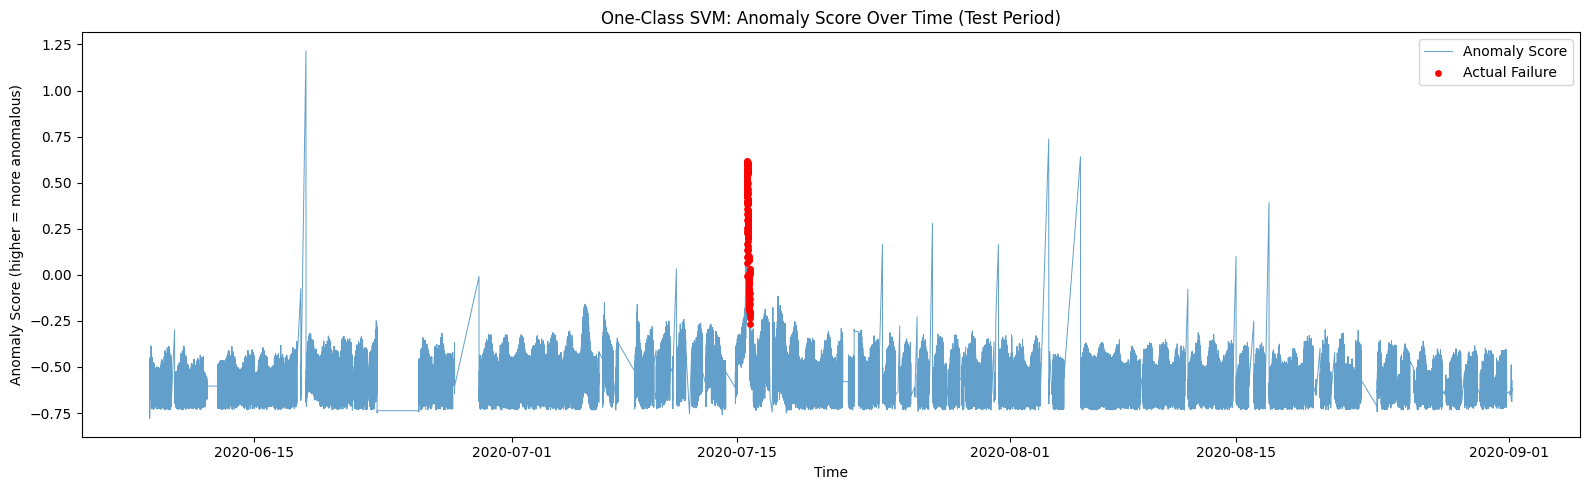

In [ ]:
import matplotlib.pyplot as plt

# Get continuous anomaly scores (not just binary decision)
# For One-Class SVM: lower score = more anomalous
scores = -oc_svm.decision_function(X_test)

test_df_plot = test_df.copy()
test_df_plot['anomaly_score'] = scores
test_df_plot['flagged'] = svm_pred_binary

plt.figure(figsize=(16, 5))
plt.plot(test_df_plot['timestamp'], test_df_plot['anomaly_score'],
         linewidth=0.7, alpha=0.7, label='Anomaly Score')

# Mark actual failure periods
actual_failures = test_df_plot[test_df_plot['is_failure'] == 1]
plt.scatter(actual_failures['timestamp'], actual_failures['anomaly_score'],
            color='red', s=15, label='Actual Failure', zorder=5)

plt.title('One-Class SVM: Anomaly Score Over Time (Test Period)')
plt.xlabel('Time')
plt.ylabel('Anomaly Score (higher = more anomalous)')
plt.legend()
plt.tight_layout()
plt.show()

## Production Considerations (Future Work)

This model is a strong learning prototype, not a production-ready system.
A real deployment would require:

1. **Root cause analysis of false positives** — investigate recurring
   false alarms (e.g., post-idle startup spikes) and add features to
   distinguish them from real failures.

2. **Human-in-the-loop feedback** — technicians confirm/reject each
   alert, building a growing labeled dataset beyond the current 4 events.

3. **Model ensembling** — combine Logistic Regression (F1=0.74) and
   One-Class SVM (F1=0.76) predictions for higher-confidence alerts
   when both agree.

4. **Confidence-tiered alerts** — use the continuous anomaly score
   (not just a binary decision) to create 🟢/🟡/🔴 alert levels instead
   of a single threshold.

5. **Periodic retraining** — mechanical wear and maintenance changes
   compressor behavior over time (concept drift); the model needs
   scheduled retraining, not a one-time fit.